# Simulacion de cartera de inversion optima

In [1]:
# Instalar librerías (solo la primera vez)
!pip -q install yfinance scipy --quiet

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Activos de tu cartera (tickers de Yahoo Finance)
activos = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 'JNJ', 'KO']

# Índices contra los cuales comparar
indices = {
    'S&P 500': '^GSPC',
    'Nasdaq 100': '^NDX',
    'Dow Jones': '^DJI',
    'Russell 2000': '^RUT'
}

# Período de análisis
fecha_inicio = '2020-01-01'
fecha_fin = '2025-12-31'

# Tasa libre de riesgo anual (bonos del tesoro USA ~4.5%)
tasa_libre_riesgo = 0.045

# Cantidad de portafolios a simular
n_portafolios = 10000

print(f"Activos seleccionados: {activos}")
print(f"Período: {fecha_inicio} a {fecha_fin}")

Activos seleccionados: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 'JNJ', 'KO']
Período: 2020-01-01 a 2025-12-31


In [3]:
print("Descargando datos de activos...")
data = yf.download(activos, start=fecha_inicio, end=fecha_fin, auto_adjust=True)['Close']
data = data.dropna()

print("Descargando datos de índices...")
data_indices = yf.download(list(indices.values()), start=fecha_inicio, end=fecha_fin, auto_adjust=True)['Close']
data_indices.columns = list(indices.keys())
data_indices = data_indices.dropna()

# Calcular retornos diarios
retornos = data.pct_change().dropna()
retornos_indices = data_indices.pct_change().dropna()

# Estadísticas anualizadas (252 días hábiles)
retorno_medio = retornos.mean() * 252
matriz_cov = retornos.cov() * 252

print(f"\n✅ Datos descargados: {len(data)} días")
print(f"\nRetornos anuales esperados de cada activo:")
print((retorno_medio * 100).round(2).astype(str) + '%')

Descargando datos de activos...


[*********************100%***********************]  8 of 8 completed
[                       0%                       ]

Descargando datos de índices...


[*********************100%***********************]  4 of 4 completed


✅ Datos descargados: 1507 días

Retornos anuales esperados de cada activo:
Ticker
AAPL     27.25%
AMZN     21.37%
GOOGL     30.9%
JNJ      10.59%
JPM      21.57%
KO         9.2%
MSFT     23.81%
NVDA     71.79%
dtype: object


In [4]:
def estadisticas_portafolio(pesos, retornos_medios, cov_matrix, rf):
    """Calcula retorno, volatilidad y Sharpe del portafolio"""
    retorno = np.sum(retornos_medios * pesos)
    volatilidad = np.sqrt(np.dot(pesos.T, np.dot(cov_matrix, pesos)))
    sharpe = (retorno - rf) / volatilidad
    return retorno, volatilidad, sharpe

def neg_sharpe(pesos, retornos_medios, cov_matrix, rf):
    return -estadisticas_portafolio(pesos, retornos_medios, cov_matrix, rf)[2]

def min_volatilidad(pesos, cov_matrix):
    return np.sqrt(np.dot(pesos.T, np.dot(cov_matrix, pesos)))

def optimizar_sharpe(retornos_medios, cov_matrix, rf):
    n = len(retornos_medios)
    args = (retornos_medios, cov_matrix, rf)
    restricciones = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    limites = tuple((0, 1) for _ in range(n))
    pesos_iniciales = np.array([1/n] * n)
    resultado = minimize(neg_sharpe, pesos_iniciales, args=args,
                        method='SLSQP', bounds=limites, constraints=restricciones)
    return resultado.x

def optimizar_min_vol(cov_matrix):
    n = cov_matrix.shape[0]
    restricciones = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    limites = tuple((0, 1) for _ in range(n))
    pesos_iniciales = np.array([1/n] * n)
    resultado = minimize(min_volatilidad, pesos_iniciales, args=(cov_matrix,),
                        method='SLSQP', bounds=limites, constraints=restricciones)
    return resultado.x

print("✅ Funciones de optimización definidas")

✅ Funciones de optimización definidas


In [5]:
# Cartera de máximo Sharpe Ratio
pesos_sharpe = optimizar_sharpe(retorno_medio, matriz_cov, tasa_libre_riesgo)
ret_sharpe, vol_sharpe, sr_sharpe = estadisticas_portafolio(pesos_sharpe, retorno_medio, matriz_cov, tasa_libre_riesgo)

# Cartera de mínima volatilidad
pesos_minvol = optimizar_min_vol(matriz_cov)
ret_minvol, vol_minvol, sr_minvol = estadisticas_portafolio(pesos_minvol, retorno_medio, matriz_cov, tasa_libre_riesgo)

# Cartera equiponderada (referencia)
pesos_eq = np.array([1/len(activos)] * len(activos))
ret_eq, vol_eq, sr_eq = estadisticas_portafolio(pesos_eq, retorno_medio, matriz_cov, tasa_libre_riesgo)

print("="*60)
print("CARTERA ÓPTIMA (Máximo Sharpe Ratio)")
print("="*60)
df_sharpe = pd.DataFrame({'Activo': activos, 'Peso (%)': pesos_sharpe * 100})
df_sharpe = df_sharpe[df_sharpe['Peso (%)'] > 0.01].sort_values('Peso (%)', ascending=False)
print(df_sharpe.to_string(index=False))
print(f"\nRetorno anual: {ret_sharpe*100:.2f}% | Volatilidad: {vol_sharpe*100:.2f}% | Sharpe: {sr_sharpe:.3f}")

print("\n" + "="*60)
print("CARTERA DE MÍNIMA VOLATILIDAD")
print("="*60)
df_minvol = pd.DataFrame({'Activo': activos, 'Peso (%)': pesos_minvol * 100})
df_minvol = df_minvol[df_minvol['Peso (%)'] > 0.01].sort_values('Peso (%)', ascending=False)
print(df_minvol.to_string(index=False))
print(f"\nRetorno anual: {ret_minvol*100:.2f}% | Volatilidad: {vol_minvol*100:.2f}% | Sharpe: {sr_minvol:.3f}")

CARTERA ÓPTIMA (Máximo Sharpe Ratio)
Activo  Peso (%)
    KO 64.539250
  AMZN 26.124354
 GOOGL  5.447018
  NVDA  3.889379

Retorno anual: 51.62% | Volatilidad: 36.72% | Sharpe: 1.283

CARTERA DE MÍNIMA VOLATILIDAD
Activo  Peso (%)
  AMZN 46.056980
   JPM 36.852580
  MSFT 12.928477
 GOOGL  3.857511
  NVDA  0.304451

Retorno anual: 12.29% | Volatilidad: 16.71% | Sharpe: 0.466


In [6]:
# Estadísticas de los índices
stats_indices = pd.DataFrame(index=list(indices.keys()),
                             columns=['Retorno Anual', 'Volatilidad', 'Sharpe'])
for nombre in indices.keys():
    ret_idx = retornos_indices[nombre].mean() * 252
    vol_idx = retornos_indices[nombre].std() * np.sqrt(252)
    sr_idx = (ret_idx - tasa_libre_riesgo) / vol_idx
    stats_indices.loc[nombre] = [ret_idx, vol_idx, sr_idx]

# Tabla comparativa
comparativa = pd.DataFrame({
    'Retorno Anual': [ret_sharpe, ret_minvol, ret_eq] + list(stats_indices['Retorno Anual']),
    'Volatilidad': [vol_sharpe, vol_minvol, vol_eq] + list(stats_indices['Volatilidad']),
    'Sharpe Ratio': [sr_sharpe, sr_minvol, sr_eq] + list(stats_indices['Sharpe'])
}, index=['Cartera Óptima (Sharpe)', 'Cartera Mín. Vol.', 'Cartera Equiponderada'] + list(indices.keys()))

comparativa['Retorno Anual'] = comparativa['Retorno Anual'].astype(float).map(lambda x: f"{x*100:.2f}%")
comparativa['Volatilidad'] = comparativa['Volatilidad'].astype(float).map(lambda x: f"{x*100:.2f}%")
comparativa['Sharpe Ratio'] = comparativa['Sharpe Ratio'].astype(float).map(lambda x: f"{x:.3f}")

print("="*60)
print("COMPARATIVA: TUS CARTERAS vs ÍNDICES")
print("="*60)
print(comparativa.to_string())

COMPARATIVA: TUS CARTERAS vs ÍNDICES
                        Retorno Anual Volatilidad Sharpe Ratio
Cartera Óptima (Sharpe)        51.62%      36.72%        1.283
Cartera Mín. Vol.              12.29%      16.71%        0.466
Cartera Equiponderada          27.06%      23.18%        0.973
S&P 500                        10.68%      20.16%        0.306
Nasdaq 100                     14.75%      20.93%        0.490
Dow Jones                      20.95%      25.67%        0.641
Russell 2000                   10.52%      27.23%        0.221


Simulando portafolios...


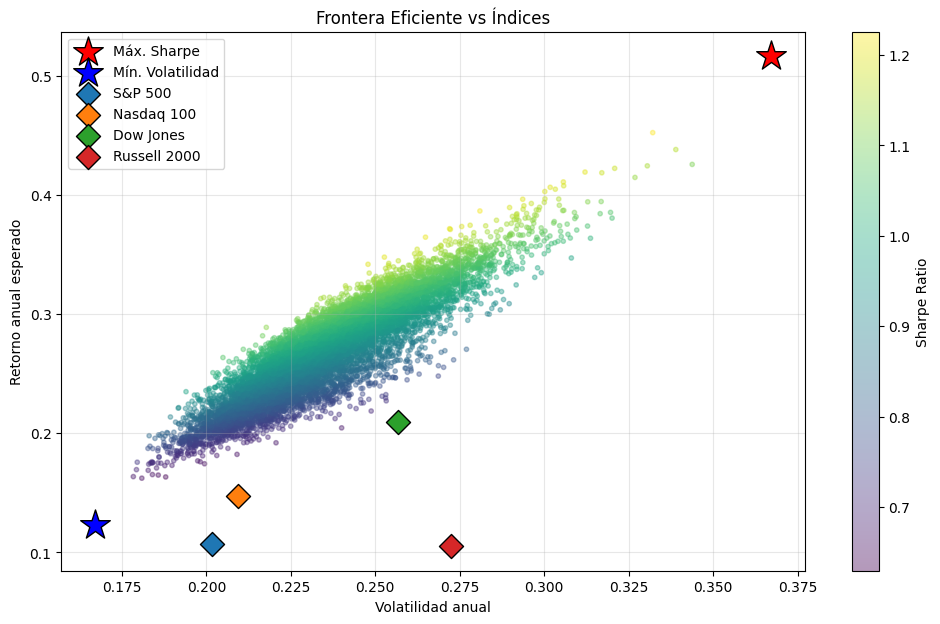

In [7]:
print("Simulando portafolios...")
np.random.seed(42)
resultados = np.zeros((3, n_portafolios))

for i in range(n_portafolios):
    pesos = np.random.random(len(activos))
    pesos /= np.sum(pesos)
    ret, vol, sharpe = estadisticas_portafolio(pesos, retorno_medio, matriz_cov, tasa_libre_riesgo)
    resultados[0, i] = ret
    resultados[1, i] = vol
    resultados[2, i] = sharpe

# Gráfico de la frontera eficiente
plt.figure(figsize=(12, 7))
scatter = plt.scatter(resultados[1, :], resultados[0, :], c=resultados[2, :],
                      cmap='viridis', alpha=0.4, s=10)
plt.scatter(vol_sharpe, ret_sharpe, marker='*', color='red', s=500, label='Máx. Sharpe', zorder=5, edgecolors='black')
plt.scatter(vol_minvol, ret_minvol, marker='*', color='blue', s=500, label='Mín. Volatilidad', zorder=5, edgecolors='black')

for nombre in indices.keys():
    ret_idx = retornos_indices[nombre].mean() * 252
    vol_idx = retornos_indices[nombre].std() * np.sqrt(252)
    plt.scatter(vol_idx, ret_idx, marker='D', s=150, label=nombre, edgecolors='black', zorder=5)

plt.colorbar(scatter, label='Sharpe Ratio')
plt.xlabel('Volatilidad anual')
plt.ylabel('Retorno anual esperado')
plt.title('Frontera Eficiente vs Índices')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

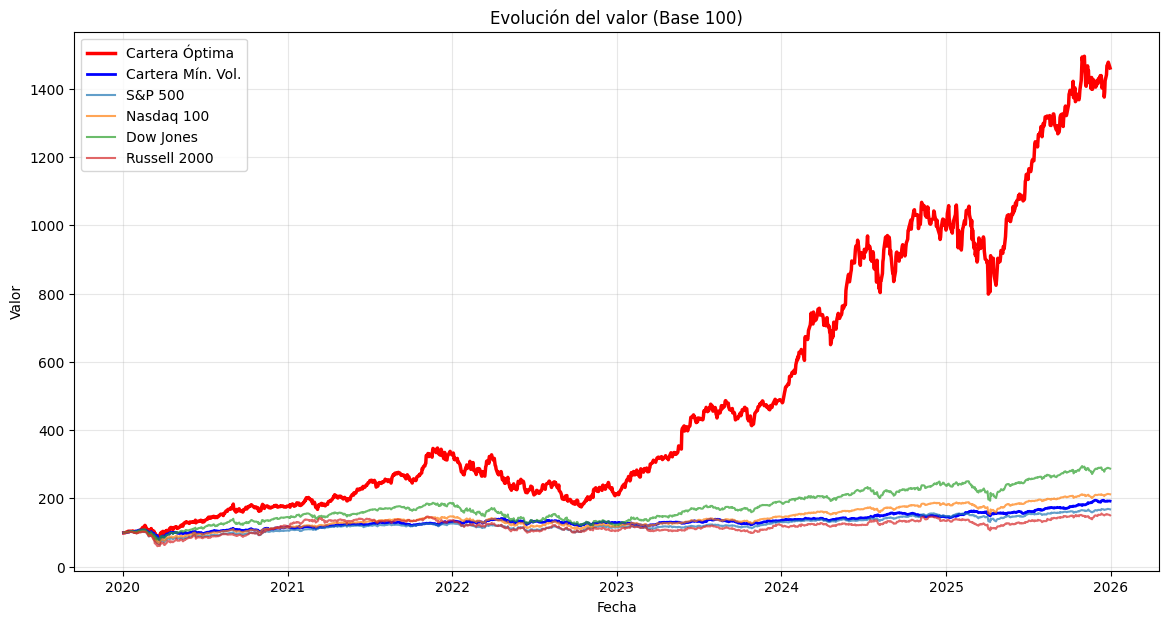

In [8]:
# Retornos de cada cartera
retornos_cartera_opt = (retornos * pesos_sharpe).sum(axis=1)
retornos_cartera_mv = (retornos * pesos_minvol).sum(axis=1)

# Valor acumulado base 100
valor_cartera_opt = (1 + retornos_cartera_opt).cumprod() * 100
valor_cartera_mv = (1 + retornos_cartera_mv).cumprod() * 100

plt.figure(figsize=(14, 7))
plt.plot(valor_cartera_opt.index, valor_cartera_opt, label='Cartera Óptima', linewidth=2.5, color='red')
plt.plot(valor_cartera_mv.index, valor_cartera_mv, label='Cartera Mín. Vol.', linewidth=2, color='blue')

for nombre in indices.keys():
    valor_idx = (1 + retornos_indices[nombre]).cumprod() * 100
    plt.plot(valor_idx.index, valor_idx, label=nombre, alpha=0.7, linewidth=1.5)

plt.title('Evolución del valor (Base 100)')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

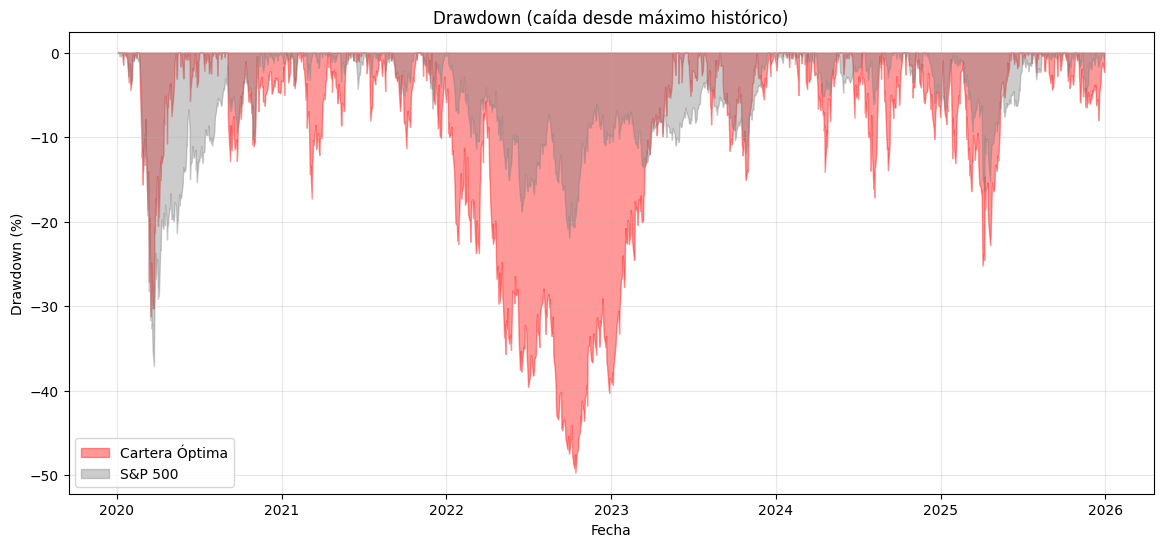

MÉTRICAS FINALES
Retorno acumulado Cartera Óptima: 1361.18%
Retorno acumulado S&P 500:        67.54%
Drawdown máximo Cartera Óptima:   -49.72%
Drawdown máximo S&P 500:          -37.09%
Beta vs S&P 500:                  1.153
Correlación con S&P 500:          0.633


In [9]:
def calcular_drawdown(serie_valor):
    pico = serie_valor.cummax()
    return (serie_valor - pico) / pico

dd_cartera = calcular_drawdown(valor_cartera_opt)
valor_sp = (1 + retornos_indices['S&P 500']).cumprod() * 100
dd_sp = calcular_drawdown(valor_sp)

plt.figure(figsize=(14, 6))
plt.fill_between(dd_cartera.index, dd_cartera * 100, 0, alpha=0.4, color='red', label='Cartera Óptima')
plt.fill_between(dd_sp.index, dd_sp * 100, 0, alpha=0.4, color='gray', label='S&P 500')
plt.title('Drawdown (caída desde máximo histórico)')
plt.ylabel('Drawdown (%)')
plt.xlabel('Fecha')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Métricas finales
print("="*60)
print("MÉTRICAS FINALES")
print("="*60)
ret_total_opt = (valor_cartera_opt.iloc[-1] / 100 - 1) * 100
ret_total_sp = (valor_sp.iloc[-1] / 100 - 1) * 100

print(f"Retorno acumulado Cartera Óptima: {ret_total_opt:.2f}%")
print(f"Retorno acumulado S&P 500:        {ret_total_sp:.2f}%")
print(f"Drawdown máximo Cartera Óptima:   {dd_cartera.min()*100:.2f}%")
print(f"Drawdown máximo S&P 500:          {dd_sp.min()*100:.2f}%")

beta = np.cov(retornos_cartera_opt, retornos_indices['S&P 500'])[0, 1] / retornos_indices['S&P 500'].var()
corr = retornos_cartera_opt.corr(retornos_indices['S&P 500'])
print(f"Beta vs S&P 500:                  {beta:.3f}")
print(f"Correlación con S&P 500:          {corr:.3f}")